
# MNIST Classification using MLP  
## Comparing Regularization vs No Regularization

### Objective
- Build a baseline MLP for MNIST digit classification  
- Add Dropout regularization  
- Compare performance with and without regularization  
- Analyze training & validation behavior  


In [1]:

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


## Load and Preprocess Data

In [2]:

(X_train, y_train), (X_dev, y_dev) = tf.keras.datasets.mnist.load_data()

# Flatten images (28x28 → 784)
X_train = X_train.reshape(-1, 784)
X_dev = X_dev.reshape(-1, 784)

# Normalize pixel values (0–255 → 0–1)
X_train = X_train / 255.0
X_dev = X_dev / 255.0


## Model With Dropout Regularization

In [3]:

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])


d:\Machine Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Model Without Regularization

In [4]:

model_no_reg = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])


## Compile Models

In [5]:

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model.compile(
    optimizer=Adam(1e-3),
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

model_no_reg.compile(
    optimizer=Adam(1e-3),
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)


## Train Models

In [6]:

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_dev, y_dev)
)

history_no_reg = model_no_reg.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_dev, y_dev)
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9208 - loss: 0.2610 - val_accuracy: 0.9640 - val_loss: 0.1136
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9629 - loss: 0.1215 - val_accuracy: 0.9715 - val_loss: 0.0896
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9713 - loss: 0.0932 - val_accuracy: 0.9728 - val_loss: 0.0868
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9764 - loss: 0.0764 - val_accuracy: 0.9797 - val_loss: 0.0726
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9787 - loss: 0.0684 - val_accuracy: 0.9775 - val_loss: 0.0743
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9391 - loss: 0.2041 - val_accuracy: 0.9676 - val_loss: 0.0989
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9733 - loss: 0.0846 - val_accuracy: 0.9721 - val_loss: 0.0878
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9816 - loss: 0.0576 - val_ac

## Visualization

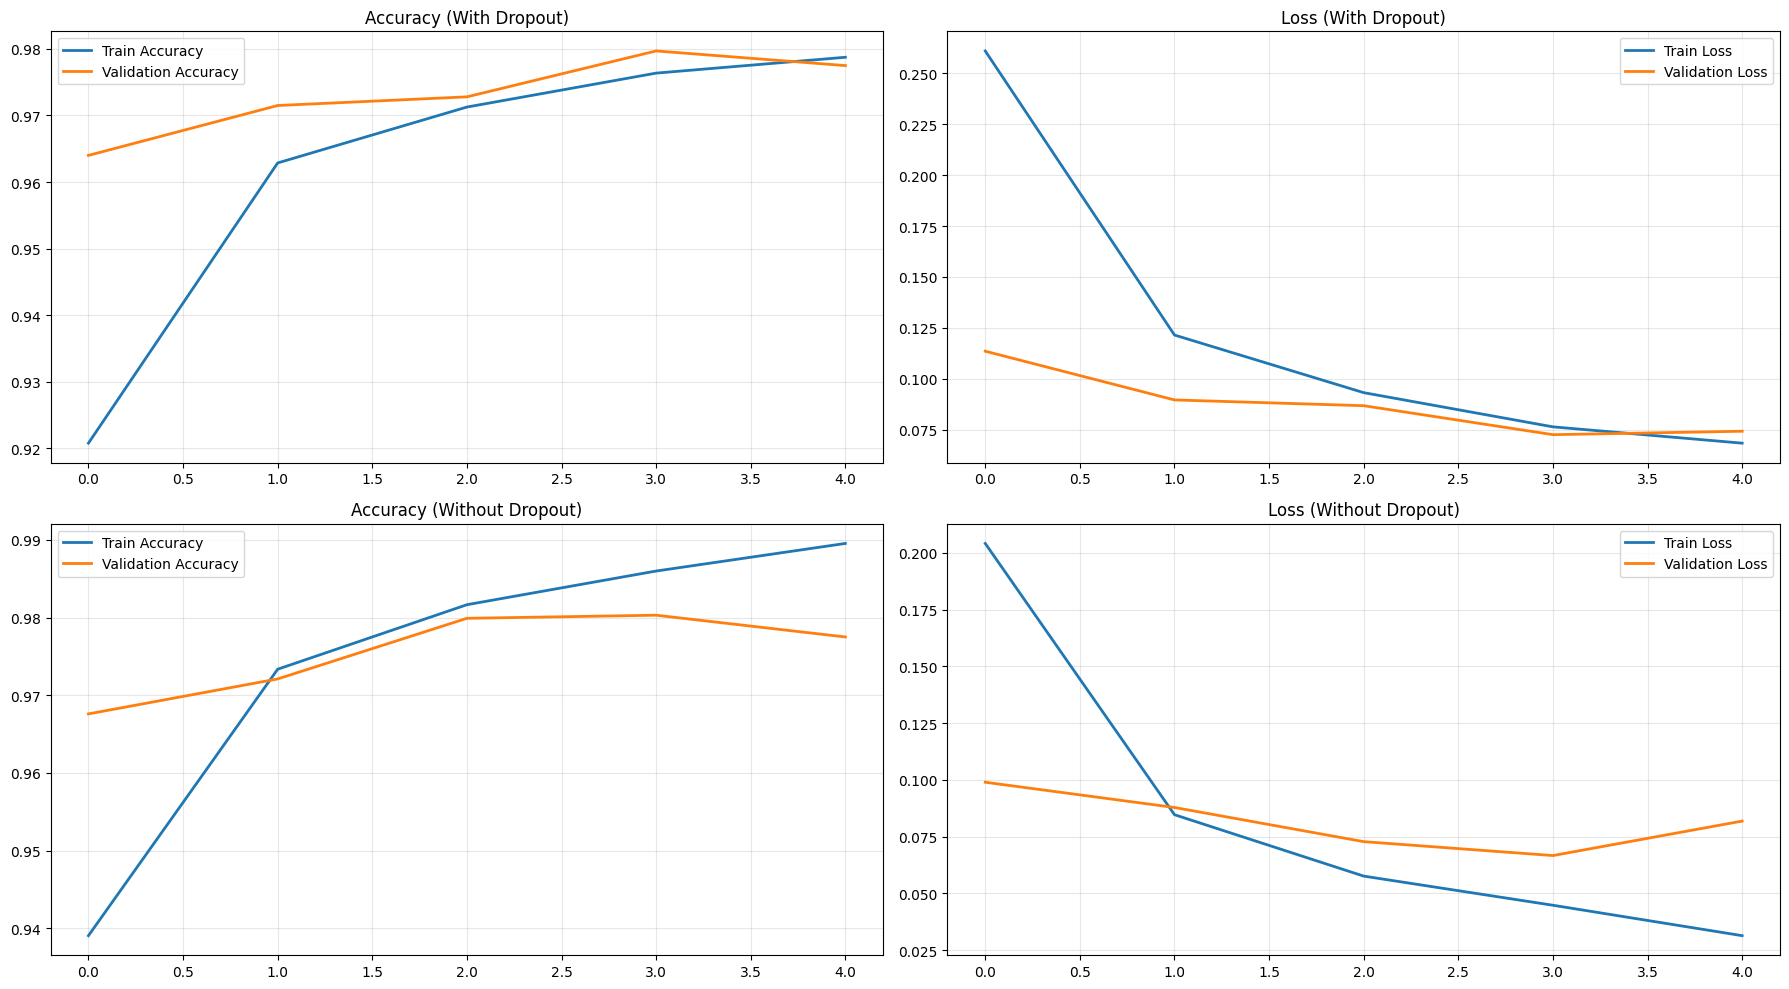

In [7]:

history_reg = history.history
history_no_reg = history_no_reg.history

fig, ax = plt.subplots(2, 2, figsize=(18, 10))

# With Regularization
ax[0, 0].plot(history_reg["accuracy"], label="Train Accuracy", linewidth=2)
ax[0, 0].plot(history_reg["val_accuracy"], label="Validation Accuracy", linewidth=2)
ax[0, 0].set_title("Accuracy (With Dropout)")
ax[0, 0].legend()

ax[0, 1].plot(history_reg["loss"], label="Train Loss", linewidth=2)
ax[0, 1].plot(history_reg["val_loss"], label="Validation Loss", linewidth=2)
ax[0, 1].set_title("Loss (With Dropout)")
ax[0, 1].legend()

# Without Regularization
ax[1, 0].plot(history_no_reg["accuracy"], label="Train Accuracy", linewidth=2)
ax[1, 0].plot(history_no_reg["val_accuracy"], label="Validation Accuracy", linewidth=2)
ax[1, 0].set_title("Accuracy (Without Dropout)")
ax[1, 0].legend()

ax[1, 1].plot(history_no_reg["loss"], label="Train Loss", linewidth=2)
ax[1, 1].plot(history_no_reg["val_loss"], label="Validation Loss", linewidth=2)
ax[1, 1].set_title("Loss (Without Dropout)")
ax[1, 1].legend()

for a in ax.flat:
    a.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Final Validation Accuracy Comparison

In [8]:

print("Final Validation Accuracy (Dropout):", history_reg["val_accuracy"][-1])
print("Final Validation Accuracy (No Dropout):", history_no_reg["val_accuracy"][-1])


Final Validation Accuracy (Dropout): 0.9775000214576721
Final Validation Accuracy (No Dropout): 0.9775000214576721
